<a href="https://colab.research.google.com/github/yadavrishikesh/Masterclass-V2-2026/blob/main/module3/code/RNN_LSTM_Demonstrations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RNNs & LSTMs: From Theory to Implementation
**Author:** Dr. Rishikesh Yadav / Vedant Vibhor

This notebook demonstrates the core concepts from the RNN/LSTM lecture, and immediately applies the "Improving Deep Learning" lecture to solve RNN-specific failures.

**Agenda:**
1. Why Feedforward Networks fail on sequences?
2. The Hidden State as Memory.
3. **The Exploding Gradient Problem & Gradient Clipping.**
4. **The Vanishing Gradient Problem (Long-Term Dependencies).**
5. Peeking inside the LSTM Cell State.
6. **Regularizing RNNs (Dropout + Early Stopping).**

In [ ]:
# --- GLOBAL IMPORTS ---
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout, Flatten
from tensorflow.keras.callbacks import EarlyStopping

# Suppress warnings for cleaner demo output
import warnings
warnings.filterwarnings('ignore')

# Setting seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

---
## Demo 1: Why Feedforward Networks Fail on Sequences
*Core Concept: FNNs treat each input as independent - they lack any notion of order.*

If we flatten a time series window and feed it to an MLP, the MLP learns step weights independently. It doesn't understand that step $t$ is directly followed by step $t+1$.


### Learning Question

Can a model understand a sequence if we remove the ordering information?

In this demonstration we compare:

- **MLP approach:** flatten the sequence into a vector.
- **RNN approach:** preserve the sequence structure.

Pay attention to the input shapes used by the two models.


In [ ]:
# Generate a simple sine wave sequence
t = np.arange(0, 20, 0.1)
series = np.sin(t)
window = 10

X, y = [], []
for i in range(len(series) - window):
    X.append(series[i:i+window])
    y.append(series[i+window])
X = np.array(X)
y = np.array(y)

print(f"Raw Input shape: {X.shape}") # (Samples, Timesteps)

Raw Input shape: (190, 10)


In [ ]:
# Approach 1: Flatten the window (MLP approach)
mlp = Sequential([Flatten(input_shape=(window,)), Dense(32, 'relu'), Dense(1)])
mlp.compile(optimizer='adam', loss='mse')

print("--- MLP Summary ---")
mlp.summary()
print("\nNotice how the Flatten layer destroys the time dimension.")

--- MLP Summary ---


Model: "sequential_83"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 385 (1.50 KB)

 Trainable params: 385 (1.50 KB)

 Non-trainable params: 0 (0.00 B)


Notice how the Flatten layer destroys the time dimension.


In [ ]:
# Approach 2: Keep the sequence shape (RNN approach)
X_rnn = X[..., np.newaxis] # Add feature dimension: (Samples, Timesteps, Features)

rnn = Sequential([SimpleRNN(32, input_shape=(window, 1)), Dense(1)])
rnn.compile(optimizer='adam', loss='mse')

print("--- RNN Summary ---")
rnn.summary()
print("\nThe RNN receives a tensor of shape `(timesteps, features)` and processes iteratively.")

--- RNN Summary ---


Model: "sequential_84"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_50 (SimpleRNN)       │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_91 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)


The RNN receives a tensor of shape `(timesteps, features)` and processes iteratively.


### What to Observe
The MLP receives a flattened vector of shape `(window,)`. The RNN receives a tensor of shape `(timesteps, features)`. Even though both contain the same numerical values, the RNN explicitly preserves temporal ordering while the MLP treats the sequence as an ordinary feature vector.

**Question:** What information is lost when we flatten a sequence?

---
## Demo 2: The Hidden State as Memory
*Core Concept: RNNs take the previous output or hidden states as part of the input at each time step.*

An RNN is essentially a loop. At each step, it calculates a new "memory" based on the old "memory" and the new input.

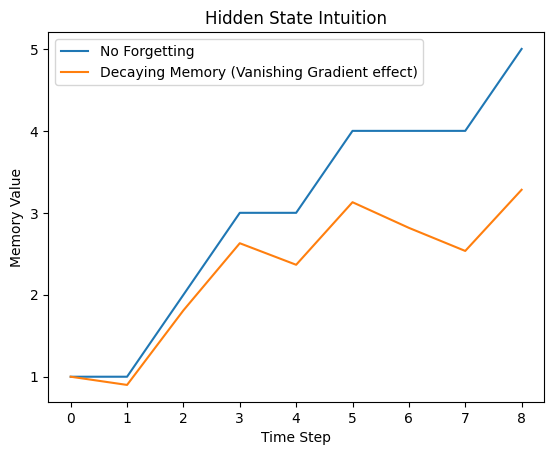

In [ ]:
sequence = [1,0,1,1,0,1,0,0,1]

memory_full = 0
memory_decay = 0

full_history=[]
decay_history=[]

for x in sequence:
    # 1. Perfect accumulation (never forgets)
    memory_full += x
    # 2. Decaying memory (forgets older information, similar to how RNNs naturally behave)
    memory_decay = 0.9*memory_decay + x

    full_history.append(memory_full)
    decay_history.append(memory_decay)

plt.plot(full_history, label="No Forgetting")
plt.plot(decay_history, label="Decaying Memory (Vanishing Gradient effect)")
plt.xlabel("Time Step")
plt.ylabel("Memory Value")
plt.legend()
plt.title("Hidden State Intuition")
plt.show()


### Full Memory vs Decaying Memory

Two memory systems are compared:

1. **Full Memory**: remembers everything seen so far.
2. **Decaying Memory**: gradually forgets older information.

This mirrors the intuition behind hidden states in recurrent networks.


---
## Demo 3: Exploding Gradients and Gradient Clipping
*Core Concept: Mitigating Exploding Gradients via Gradient Clipping.*

We use a deliberately large learning rate with a longer sequence. One model has no clipping (loss diverges to infinity), while the other uses `clipnorm=1.0` to keep the loss stable.

In [ ]:
# Generate a long sequence to make Backprop Through Time unstable
t = np.arange(0, 500, 0.1)
series = np.sin(t)
window = 75 # Long window = deeper unrolled graph = higher gradient explosion risk

X, y = [], []
for i in range(len(series) - window):
    X.append(series[i:i+window])
    y.append(series[i+window])

X = np.array(X)[..., np.newaxis]
y = np.array(y)

split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
print("Training sequences:", X_train.shape)

Training sequences: (3940, 75, 1)


In [ ]:
# Model 1: High learning rate WITHOUT clipping
rnn_fail = Sequential([
    SimpleRNN(64, activation='relu', input_shape=(window, 1)),
    Dense(1)
])
rnn_fail.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.7), loss='mse')

hist_fail = rnn_fail.fit(X_train, y_train, epochs=10, verbose=1)

Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: nan
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: nan
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: nan
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: nan
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: nan
Epoch 6/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: nan
Epoch 7/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: nan
Epoch 8/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: nan
Epoch 9/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: nan
Epoch 10/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: nan



### Important Note

Modern TensorFlow implementations are numerically stable.
Exploding gradients do **not necessarily produce NaNs**.

Instead, we look for:

- unstable loss curves,
- oscillating optimization,
- poor convergence.

Gradient clipping constrains updates and stabilizes training.


Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.2164
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0593
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0029
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0031
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0046
Epoch 6/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0052
Epoch 7/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0050
Epoch 8/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0042
Epoch 9/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0044
Epoch 10/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0041


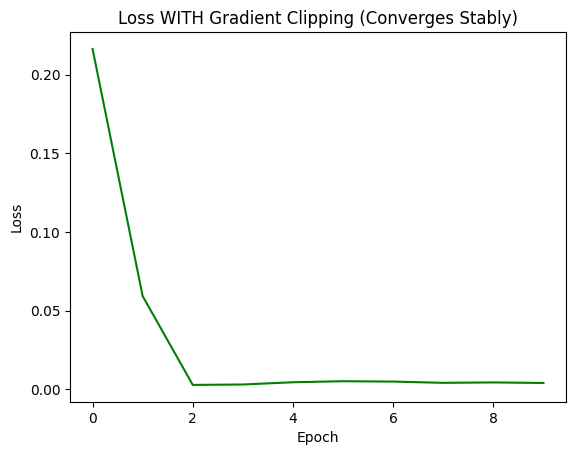

In [ ]:
# Model 2: Same high learning rate WITH clipping
# If ||gradient|| > 1, TensorFlow rescales it to 1.
rnn_clip = Sequential([
    SimpleRNN(64, activation='relu', input_shape=(window, 1)),
    Dense(1)
])
rnn_clip.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.7, clipnorm=1.0), loss='mse')

hist_clip = rnn_clip.fit(X_train, y_train, epochs=10, verbose=1)

plt.plot(hist_clip.history['loss'], color='green')
plt.title("Loss WITH Gradient Clipping (Converges Stably)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

---
## Demo 4: The Vanishing Gradient Problem (Long-Term Dependencies)
 *Core Concept: Standard RNNs suffer from vanishing gradients - difficult to learn long-range dependencies.*

### **The Addition Task:**
 We generate a sequence of 100 zeros. We drop two random numbers (between 0.1 and 0.9) at random positions. The target is the **sum** of those two numbers.

 The network cannot use local patterns. It must explicitly store the first number in memory, carry it over dozens of timesteps, and retrieve it when it sees the second number.


In [ ]:
def generate_addition_data(n_samples, timesteps):
    X = np.zeros((n_samples, timesteps, 1), dtype=np.float32)
    y = np.zeros((n_samples, 1), dtype=np.float32)

    for i in range(n_samples):
        # Place first number in the first half, second in the second half
        idx1 = np.random.randint(0, timesteps // 2)
        idx2 = np.random.randint(timesteps // 2, timesteps)

        val1 = np.random.uniform(0.1, 0.9)
        val2 = np.random.uniform(0.1, 0.9)

        X[i, idx1, 0] = val1
        X[i, idx2, 0] = val2
        y[i, 0] = val1 + val2  # Target is the sum

    return X, y

seq_len = 100
X_train, y_train = generate_addition_data(5000, seq_len)
X_test, y_test = generate_addition_data(500, seq_len)

print(f"Sequence length: {seq_len} timesteps.")
print(f"Example target (sum): {y_train[0][0]:.2f}")

Sequence length: 100 timesteps.
Example target (sum): 0.97


#### Why this breaks SimpleRNNs:
At every zero timestep, the RNN calculates: $h_t = \tanh(W_{hh} h_{t-1} + 0)$.
Multiplying by $W_{hh}$ and squashing with `tanh` continuously degrades the signal. By the time it sees the second number, the first number is mathematically "forgotten".


In [ ]:
# SimpleRNN attempt
rnn_add = Sequential([SimpleRNN(32), Dense(1)])
rnn_add.compile(optimizer='adam', loss='mse')

print("Training SimpleRNN on Addition Task...")
rnn_add.fit(X_train, y_train, epochs=15, verbose=0)
rnn_mse = rnn_add.evaluate(X_test, y_test, verbose=0)
print(f"SimpleRNN Test MSE: {rnn_mse:.4f}\n")

# LSTM attempt
lstm_add = Sequential([LSTM(32), Dense(1)])
lstm_add.compile(optimizer='adam', loss='mse')

print("Training LSTM on Addition Task...")
lstm_add.fit(X_train, y_train, epochs=15, verbose=0)
lstm_mse = lstm_add.evaluate(X_test, y_test, verbose=0)
print(f"LSTM Test MSE: {lstm_mse:.4f}")

Training SimpleRNN on Addition Task...
SimpleRNN Test MSE: 0.1009

Training LSTM on Addition Task...
LSTM Test MSE: 0.0006


In [ ]:
# Let's look at actual predictions for 5 test samples to see the difference

predictions_rnn = rnn_add.predict(X_test[:5], verbose=0).flatten()
predictions_lstm = lstm_add.predict(X_test[:5], verbose=0).flatten()
true_values = y_test[:5].flatten()

print(f"{'True Sum':<10} | {'RNN Pred':<10} | {'LSTM Pred':<10}")
print("-" * 35)
for true, rnn_p, lstm_p in zip(true_values, predictions_rnn, predictions_lstm):
    print(f"{true:<10.2f} | {rnn_p:<10.2f} | {lstm_p:<10.2f}")


True Sum   | RNN Pred   | LSTM Pred 
-----------------------------------
1.30       | 0.96       | 1.32      
0.61       | 0.96       | 0.63      
1.20       | 0.96       | 1.23      
1.18       | 0.96       | 1.19      
1.45       | 0.96       | 1.49      



### What to Observe
- The **SimpleRNN predictions** will default to predicting the average sum (around ~0.95 to 1.0) regardless of the input. It has completely lost the specific values due to vanishing gradients.
- The **LSTM predictions** will closely match the True Sum. The Cell State acted as a carrier for the first number until the addition could occur.

---
## Demo 5: Regularizing RNNs (Bridging to Improving DLs)
*Improving DL: Dropout, Early Stopping.*

RNNs overfit just like CNNs. However, standard Dropout destroys the recurrent memory loop. We must use `recurrent_dropout` (drops connections between recurrent steps) alongside standard `Dropout`.

Training UNREGULARIZED LSTM on tiny noisy data:


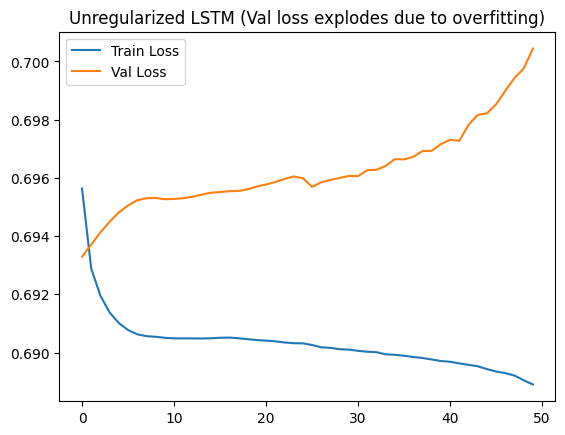

In [ ]:
# Create a small noisy dataset to force overfitting
X_small = np.random.rand(100, 20, 1)
y_small = np.random.randint(0, 2, (100, 1))

# Model WITHOUT regularization
lstm_overfit = Sequential([
    LSTM(64, input_shape=(20, 1)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
lstm_overfit.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training UNREGULARIZED LSTM on tiny noisy data:")
history_overfit = lstm_overfit.fit(X_small, y_small, epochs=50, verbose=0, validation_split=0.2)

plt.plot(history_overfit.history['loss'], label='Train Loss')
plt.plot(history_overfit.history['val_loss'], label='Val Loss')
plt.title("Unregularized LSTM (Val loss explodes due to overfitting)")
plt.legend(); plt.show()

Training REGULARIZED LSTM:


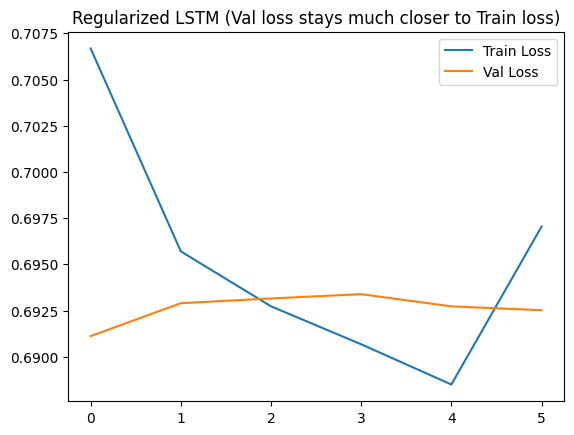

In [ ]:
# Model WITH RNN-specific Regularization
lstm_regularized = Sequential([
    # Dropout drops input connections. Recurrent Dropout drops the hidden state loop.
    LSTM(64, input_shape=(20, 1), dropout=0.3, recurrent_dropout=0.3),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
lstm_regularized.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Add Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Training REGULARIZED LSTM:")
history_reg = lstm_regularized.fit(
    X_small, y_small,
    epochs=50,
    verbose=0,
    validation_split=0.2,
    callbacks=[early_stop] # Stops before severe overfitting
)

plt.plot(history_reg.history['loss'], label='Train Loss')
plt.plot(history_reg.history['val_loss'], label='Val Loss')
plt.title("Regularized LSTM (Val loss stays much closer to Train loss)")
plt.legend(); plt.show()

### Key Takeaways
- FNNs destroy temporal order; RNNs preserve it via hidden states.
- **Long sequences = Exploding Gradients.** Fix: `optimizer = SGD(clipnorm=1.0)`.
- **Long-term memory = Vanishing Gradients.** Fix: Upgrade to LSTM (Cell State acts as a conveyor belt).
- **RNNs overfit too.** Fix: Use `dropout` + `recurrent_dropout` + `EarlyStopping`.